In [ ]:
import pandas as pd
import os

In [ ]:
file_path_red = '/content/winequality-red.csv'
file_path_white = '/content/winequality-white.csv'

In [ ]:
# Load the datasets
red_wine = pd.read_csv(file_path_red, sep=";")
white_wine = pd.read_csv(file_path_white, sep=";")

In [ ]:
print(red_wine.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [ ]:
print(white_wine.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

In [ ]:
# Add the label column (1 for red wine, 0 for white wine)
red_wine["label"] = 1
white_wine["label"] = 0

In [ ]:
# Combine both datasets into one DataFrame
wines = pd.concat([red_wine, white_wine], ignore_index=True)

In [ ]:
# Display the first few rows of the combined dataset
wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [ ]:
import matplotlib.pyplot as plt

# Display basic statistics of the combined dataset
print(wines.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

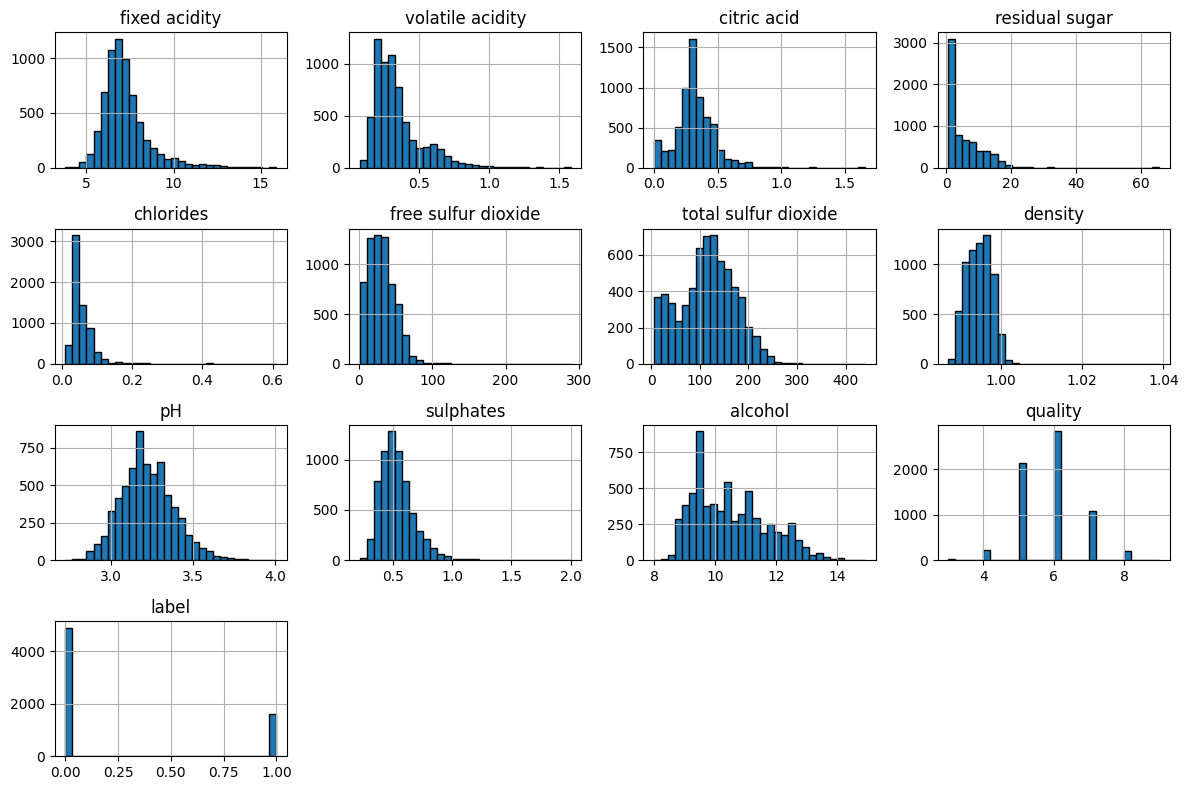

In [ ]:
# Plot histograms for all numerical columns in the dataset
wines.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.tight_layout()  # Reduces overlap between subplots
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and labels (y)
X = wines.drop('label', axis=1)  # Drop the 'label' column to get features
y = wines['label']  # The 'label' column is the target variable

In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Display the shapes of the resulting sets
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")
print(f"Training labels shape (y_train): {y_train.shape}")
print(f"Testing labels shape (y_test): {y_test.shape}")

Training data shape (X_train): (5197, 12)
Testing data shape (X_test): (1300, 12)
Training labels shape (y_train): (5197,)
Testing labels shape (y_test): (1300,)


In [ ]:
from keras import models
from keras import layers

# Create a sequential model
model = models.Sequential()

# Add the first Dense layer with 8 neurons and ReLU activation
model.add(layers.Dense(8, activation='relu', input_shape=(12,)))

# Add the second Dense layer with 8 neurons and ReLU activation
model.add(layers.Dense(8, activation='relu'))

# Add the output layer with 1 neuron (for binary classification)
model.add(layers.Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam',              # Adam optimizer
              loss='binary_crossentropy',     # Binary crossentropy loss function for binary classification
              metrics=['accuracy'])          # Accuracy metric

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4626 - loss: 16.6273 - val_accuracy: 0.9223 - val_loss: 0.2220
Epoch 2/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9365 - loss: 0.1881 - val_accuracy: 0.9215 - val_loss: 0.2309
Epoch 3/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9410 - loss: 0.1759 - val_accuracy: 0.9285 - val_loss: 0.2030
Epoch 4/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9416 - loss: 0.1663 - val_accuracy: 0.9262 - val_loss: 0.1996
Epoch 5/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9413 - loss: 0.1585 - val_accuracy: 0.9354 - val_loss: 0.1774
Epoch 6/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9483 - loss: 0.1447 - val_accuracy: 0.9431 - val_loss: 0.1636
Epoch 7/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9532 - loss: 0.1349 - val_accuracy: 0.9415 - val_loss: 0.1624
Epoch 8/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9591 - loss: 0.1167 - val_accuracy: 0

In [ ]:
# Get the final accuracy and loss
final_accuracy = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]

print(f"Final Accuracy: {final_accuracy:.4f}")
print(f"Final Loss: {final_loss:.4f}")

Final Accuracy: 0.9748
Final Loss: 0.0757


In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize the scaler
scaler = StandardScaler()

# Standardize the features (X_train and X_test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a new model with 2 Dense layers and 1 output layer
model_scaled = Sequential()
model_scaled.add(Dense(8, activation='relu', input_shape=(12,)))
model_scaled.add(Dense(8, activation='relu'))
model_scaled.add(Dense(1, activation='sigmoid'))

# Compile the model
model_scaled.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with the scaled data
history_scaled = model_scaled.fit(X_train_scaled, y_train, epochs=20, batch_size=16, validation_data=(X_test_scaled, y_test))

# Get the final accuracy and loss after training
final_accuracy_scaled = history_scaled.history['accuracy'][-1]
final_loss_scaled = history_scaled.history['loss'][-1]

# Print the results
print(f"Final Accuracy with Scaling: {final_accuracy_scaled:.4f}")
print(f"Final Loss with Scaling: {final_loss_scaled:.4f}")

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7615 - loss: 0.4012 - val_accuracy: 0.9692 - val_loss: 0.2037
Epoch 2/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9836 - loss: 0.1389 - val_accuracy: 0.9838 - val_loss: 0.0722
Epoch 3/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9910 - loss: 0.0455 - val_accuracy: 0.9854 - val_loss: 0.0618
Epoch 4/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9921 - loss: 0.0292 - val_accuracy: 0.9869 - val_loss: 0.0575
Epoch 5/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9928 - loss: 0.0384 - val_accuracy: 0.9877 - val_loss: 0.0551
Epoch 6/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9937 - loss: 0.0272 - val_accuracy: 0.9885 - val_loss: 0.0524
Epoch 7/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9938 - loss: 0.0243 - val_accuracy: 0.9892 - val_loss: 0.0496
Epoch 8/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9950 - loss: 0.0248 - val_accuracy: 0.9892 - val_

In [ ]:
# Evaluate the model on the test set (scaled data)
test_loss, test_accuracy = model_scaled.evaluate(X_test_scaled, y_test)

# Print the accuracy and loss
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9960 - loss: 0.0198
Test Accuracy: 0.9946
Test Loss: 0.0294
